# Estimating Covariance Structures
As mentioned in the introduction, although a general covariance structure is *desirable*, this comes with consequences in terms of inference. In this first part of the lesson, we will focus on understanding precisely what the issue is with using a general covariance structure. In the next part of the lesson, we will then discuss possible "solutions" to this problem, before turning our attention to Generalised Least Squares (GLS).

## The Basic Problem
Recall that we refer to the variance–covariance matrix as $\boldsymbol{\Sigma}$, as a direct analog of the single variance term $\sigma^{2}$ from the normal linear model. Conceptually, $\boldsymbol{\Sigma}$ plays the same role, describing the scale and structure of the noise in the data. From a mathematical point of view, the natural generalisation of everything we have done so far is to simply replace $\sigma^{2}$ with $\boldsymbol{\Sigma}$ in the expressions used for the normal linear model. When $\boldsymbol{\Sigma}$ is known, this causes no fundamental difficulties as $\boldsymbol{\Sigma}$ behaves like a constant object. There is no additional randomness and the underlying theory remains intact. In this sense, moving from a single variance to a full covariance matrix does not, by itself, create any new problems.

However, the reality is that we will *almost never* know $\boldsymbol{\Sigma}$ *a priori*. As such, we will almost always be in a position where we need to *estimate* it from the data. Once we do that, the term $\boldsymbol{\Sigma}$ is no longer a *fixed constant*. Instead, we have $\hat{\boldsymbol{\Sigma}}$, which is a *random variable*. This introduces an additional layer of uncertainty that causes some major issues. We will discuss the full story below, but the short version is that treating $\hat{\boldsymbol{\Sigma}}$ as an *estimate* means we no longer know how the standard errors are distributed. This means we cannot work out what null distribution our test statistics have and thus cannot calculate a $p$-value. In short, *all our inferential machinery breaks*.

## How Estimating $\boldsymbol{\Sigma}$ Breaks Inference
We are going to spend a bit of time discussing the reasons *why* having an arbitrary covariance structure causes classical inference to fall apart. This is a bit of a detour and can get a little complicated. However, stick with it, because by the end you will have a clearer sense of why our *desire* to have an unstructured covariance matrix does not actually gel with the classical inferential machinery. This is important going forward because we need to recognise that *all* the models we will discuss have this problem. Classical inference is *fragile*. As soon as we step outside a very fixed structure, it will break.


### Revisiting the Normal Linear Model
To start understanding *why* an arbitrary covariance structure is problematic, we need to go back to some of the information covered last semester on [Statistical Inference](https://pchn63101-advanced-data-skills.github.io/Inference-Linear-Model/2.estimation-uncertainty.html). Focusing on the normal linear model, we start from the position of assuming we know what $\sigma^{2}$ is. If this is true, then the standard errors of the parameter estimates are a *constant* quantity. If the assumptions of the model are met, then the parameter estimates have a known distribution. For example, a single slope from a typical regression model has the distribution

$$
\hat{\beta}_{1} \sim \mathcal{N}\left(\beta_{1}, \frac{\sigma^{2}}{\sum{(x_{i} - \bar{x})^{2}}}\right).
$$

The standard error is just the square-root of this variance term

$$
\text{SE}\left(\hat{\beta}_{1}\right) = \sqrt{\frac{\sigma^{2}}{\sum{(x_{i} - \bar{x})^{2}}}}
$$

which depends upon knowing $x$ (the associated predictor variable) and $\sigma^{2}$. This becomes important when we form a test statistic and want to know its null distribution. In the case where $\sigma^{2}$ is a *constant* then the standard error is *also constant*. This means that if we calculate 

$$
z = \frac{\hat{\beta}_{1}}{\text{SE}\left(\hat{\beta}_{1}\right)},
$$

we are just dividing a random variable by a constant. This does not change its distribution, only its *scale*. So, under the null hypothesis that $\beta_{1} = 0$, the null distribution of $z$ is 

$$
z \sim \mathcal{N}(0,1).
$$

This is exactly how inference was conducted before Student came along. Prior to Student's insights, statisticians always treated the variance *as if it were known*. 

So, what happens in the more *realistic* scenario when $\sigma^{2}$ is *not* known, and must be replaced by its estimate $\hat{\sigma}^{2}$? This was Student's great contribution. The main change is that the *standard errors* also become *estimates*

$$
\widehat{\text{SE}}\left(\hat{\beta}_{1}\right) = \sqrt{\frac{\hat{\sigma}^{2}}{\sum{(x_{i} - \bar{x})^{2}}}}, 
$$

which means that our test statistic is no longer a simple *scaling* of $\hat{\beta}_{1}$. Instead, it now has the form

$$
t = \frac{\hat{\beta}_{1}}{\widehat{\text{SE}}\left(\hat{\beta}_{1}\right)},
$$

which is a ratio between *two* random variables. Using an *estimate* of the standard error therefore adds an additional layer of uncertainty that needs to be accounted for. 

In order to understand how this new uncertainty affects the behaviour of the test statistic, we need to know the *sampling distribution* of $\hat{\sigma}^{2}$. We glossed-over this detail last semester, but under the normal linear model the variance estimate has the following sampling distribution

$$
\hat{\sigma}^{2} \sim \frac{\sigma^{2}}{\nu}\chi^{2}(\nu),
$$

which is a scaled $\chi^{2}$ distribution with $\nu$ degrees of freedom. We will explore this in more detail below.

### Understanding the Scaled $\chi^{2}$ Distribution
Ignoring the *scaled* aspect, the usual $\chi^{2}$ distribution is written, for some random variable $Y$, as

$$
Y \sim \chi^{2}(\nu).
$$

Notice that there is only a *single* parameter, $\nu$, called the *degrees of freedom*. The $\chi^{2}(\nu)$ distribution comes from summing squared normal random variates, so $\nu$ is simply the count of the number of random variables that form this sum. What this means practically is that both the *mean* and *variance* are functions of $\nu$. So, we have

$$
\begin{alignat*}{1}
    E(Y)          &= \nu \\
    \text{Var}(Y) &= 2\nu.
\end{alignat*}
$$

The most important element to notice is that $\nu$ controls the *width* of the distribution. Thus, the *uncertainty* around the value of $Y$ can be quantified using $\nu$ alone. This is very important for understanding *why* degrees of freedom matter. However, the fact that $\nu$ controls both the *width* and the *centre* of the distribution is a problem, which is why the version of the $\chi^{2}(\nu)$ distribution used for the variance estimate is *scaled*. This is explored more in the box below.

````{admonition} Why is this a *scaled* $\chi^{2}$?
:class: tip
As mentioned above, the fact that $\nu$ controls both the *width* of the distribution *and* the *mean* is problematic. As a sampling distribution for $\hat{\sigma}^{2}$, we can get the *shape* correct by using a suitable value for $\nu$. However, this will not necessarily be *scaled* correctly. For instance, $\chi^{2}(5)$ may well have the right *width* to capture the uncertainty in $\hat{\sigma}^{2}$, but this would only work with data where $\sigma^{2} = 5$. 

Because of this, the sampling distribution of $\hat{\sigma}^{2}$ *cannot* be a plain old $\chi^{2}(\nu)$ distribution, because the units would be wrong. Therefore, the actual sampling distribution must be a *scaled* version of the $\chi^{2}(\nu)$. This allows both the *shape* to be correct and the *units* to be correct. 

To see how this scaling works, notice that if we were to multiply the whole distribution by $\sigma^{2}$, then the expected value would be $\sigma^{2} \times \nu$. This is obviously $\nu$-times too big. So, if we first *divide* $\sigma^{2}$ by $\nu$, then the expected value becomes $\frac{\sigma^{2}}{\nu} \times \nu = \sigma^{2}$. We then end up with a distribution with the correct *width* (encoded by the *degrees of freedom*) and the correct *units* (because we scaled the distribution by $\sigma^{2}/\nu$).
````

Importantly, because the degrees of freedom are tied directly to the *sample size* (because $\nu = n - p$), as $n$ increases, so too does $\nu$. Indeed, Student's original insights related directly to *small samples*, because he did not believe that results using $z$-tests and the standard normal distribution held when $n$ was small. So, let us have a look and see what happens to the scaled $\chi^{2}$ when $n$ is small. We can then increase $n$ and see what happens. 

Below are 6 plots demonstrating what happens to the *width* of a scaled $\chi^{2}$ distribution as the sample size moves from *small* (giving $\nu=5$) to *large* (giving $\nu=500,000$).

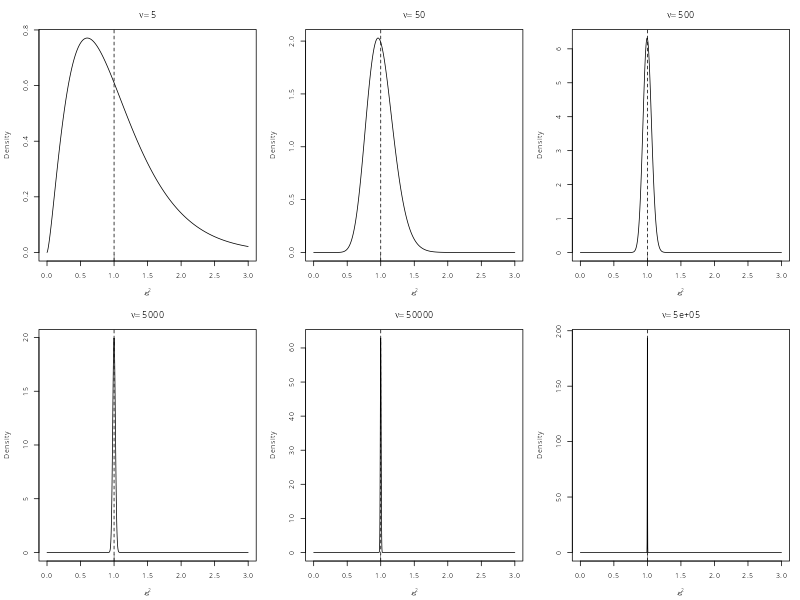

In [2]:
# Visualise the scaled chi-square variance estimator:
#   s2_hat = (sigma2 / nu) * X,  where X ~ chisq(nu)
# so s2_hat is centred on sigma2 and collapses onto sigma2 as nu grows.

sigma2 <- 1
dfs <- c(5, 50, 500, 5000, 50000, 500000)

# Density of s2_hat via change-of-variables:
# If S = (sigma2/nu) X, then f_S(s) = (nu/sigma2) * f_X((nu/sigma2)*s)
d_scaled_chisq <- function(s, nu, sigma2) {
  (nu / sigma2) * dchisq((nu / sigma2) * s, df = nu)
}

# Choose an x-range that makes the "collapse" obvious
x <- seq(0, 3, length.out = 2000)

# Pre-compute a common y-limit so all plots are comparable
ymax <- max(sapply(dfs, function(nu) max(d_scaled_chisq(x, nu, sigma2))))

op <- par(mfrow = c(2,3), mar = c(4, 4, 3, 1) + 0.1)
on.exit(par(op), add = TRUE)

for (nu in dfs) {
  y <- d_scaled_chisq(x, nu, sigma2)

  plot(x, y, type = "l",
       xlab = expression(hat(sigma)^2),
       ylab = "Density",
       xlim = c(0,3),
       main = bquote(nu == .(nu)))
  #     main = bquote(frac(sigma^2,nu) * chi^2 * "(" * nu * ")"))

  abline(v = sigma2, lty = 2)          # true variance
  rug(c(sigma2), ticksize = 0.03)
  #legend("topright",
  #       legend = c(bquote(nu == .(nu)), bquote(sigma^2 == .(sigma2))),
  #       bty = "n")
}

# If you want to *really* see the collapse for large nu, try narrowing xlim:
# e.g., set x <- seq(0.6, 1.4, length.out=2000) and xlim=c(0.6,1.4)


Notice the pattern here. As the degrees of freedom go *up*, the width of the scaled $\chi^{2}$ distribution *shrinks*. When the sample size is *small*, the distribution is very *wide* because there is a lot of uncertainty around the true value of $\sigma^{2}$. As the sample size gets *larger*, this uncertainty gets smaller and smaller until it effectively *vanishes*. So, the degrees of freedom exist *precisely* because they encode this uncertainty around $\hat{\sigma}^{2}$. Once they get large enough, the distribution is effectively a single point sat on the true variance and, for all practical purposes, we *know* $\sigma^{2}$. 

So, we can reach two clear conclusions from this:

1. The degrees of freedom tell us *directly* about the uncertainty of our estimate $\hat{\sigma}^{2}$.
2. This uncertainty scales with sample size so, at a certain point, degrees of freedom do not matter anymore.

### The Origin of the $t$-distribution
So, how does this behaviour of the scaled $\chi^{2}(\nu)$ connect to the null distribution of the test statistic? Well, we know that if you divide a normal random variate by a *constant* you just get another normal random variate on a different scale. Hence, when $\sigma^{2}$ is known, we get a $z$-statistic with a null distribution that is a standard normal. This takes none of the additional uncertainty around $\hat{\sigma}^{2}$ into account and thus is only suitable if we (a) know what $\sigma^{2}$ is *a priori* or (b) have so much data that the scaled $\chi^{2}(\nu)$ has effectively collapsed to a single point. In both cases, we treat the denominator of the test statistic as a *constant*.

So, what happens when you instead divide a normal random variate by a scaled $\chi^{2}(\nu)$ random variate? This is what Student discovered. Rather than a random variable with a *fixed* distribution, you get a random variable whose distribution changes *dynamically* depending upon the degree of uncertainty. Because the denominator depends upon $\hat{\sigma}^{2}$, this uncertainty is captured directly by $\nu$ and the result is a $t$-distribution with $\nu$ degrees of freedom. The degrees of freedom are passed *directly* from the scaled $\chi^{2}(\nu)$ distribution to the $t$-distribution and the $t$-distribution changes its shape accordingly.

When the sample size is *small*, so too is that value of $\nu$. As seen in the plots above, this is associated with a much *wider* sampling distribution of $\hat{\sigma}^{2}$. This causes the $t$-distribution to shift its shape more dramatically away from a standard normal. As the same size goes *up*, so too does $\nu$. This makes the uncertainty around $\sigma^{2}$ shrink, causing the $t$-distribution to shift only slightly away from a standard normal. At a certain point, the uncertainty is so small that $\sigma^{2}$ effectively becomes known and the $t$-distribution *becomes* a standard normal distribution. Indeed, if you plug $\nu = \infty$ into the definition of a $t$-distribution, it simplifies to a standard normal. 

### What Happens When We Use $\hat{\boldsymbol{\Sigma}}$?
Taking all the information above, we have established that inference in the normal linear model is only possible when using an estimate of $\sigma^{2}$ *if* we know its sampling distribution. The logic we have established is:

- If $\sigma^{2}$ is known then there is a simple and basic result we can use to calculate a $p$-value using a standard normal distribution.
- If $\sigma^{2}$ is *not* known, then we need to replace it with $\hat{\sigma}^{2}$, which is an *estimate* from the data.
- The process of estimation introduces an additional layer of *uncertainty* into the calculations, because we do not know how close our estimate is to the true value.
- Quantification of this uncertainty requires knowing the distribution of $\hat{\sigma}^{2}$ which, under the normal linear model, is a scaled $\chi^{2}$ distribution with $\nu$ degrees of freedom.
- Because of this derivation, the uncertainty in $\hat{\sigma}^{2}$ is directly captured by the value of $\nu$.
- This uncertainty passes into the calculation of a test statistic, shifting its distribution *dynamically* depending upon the value of $\nu$. This is *where* the $t$-distribution comes from.
- The value of $\nu$ can therefore be used to work out how *far off* we are from a standard normal distribution, given our sample size, and thus calculate a more accurate $p$-value.

These steps all work because of various useful properties of the standard normal distribution. Not least the fact that the errors are assumed independent normal variates and thus squaring and summing them leads *precisely* to a $\chi^2$-like distribution. But think about how *fragile* this process is. If anything fails during any one of the steps above, nothing works anymore. 

Unfortunately, this is *exactly* what happens when we start using an estimate of a complex variance-covariance matrix. When we start trying to work with $\hat{\boldsymbol{\Sigma}}$ we get stuck at the point of trying to work out the sampling distribution of the variance estimates. In the normal linear model there is *one* variance term with a simple definition that leads directly to a scaled $\chi^{2}(\nu)$ distribution. Once we start playing around with multiple variances and covariances interacting in different ways, this clean definition disappears. Once this disappears, the sampling distribution is no longer a scaled $\chi^{2}(\nu)$ distribution. In fact, the sampling distribution has no simple single form that applies no matter what structure $\hat{\boldsymbol{\Sigma}}$ has.

The consequence is that, without a known singular form, we do not know what distribution our test statistic will have under the null. We have lost the simple situation that leads to the $t$-distribution. There is no universal $\chi^{2}(\nu)$ distribution anymore. As such, there is no single parameter $\nu$ that captures our uncertainty and can be passed to the distribution of the test statistic. This means we have no way of calculating $p$-values or confidence intervals. 

We are, in effect, *stuck*.

````{admonition} Compound Symmetry
:class: tip
The only exception to the dire situation described above is when the covariance structure is *compound symmetric*. This is a *special case* where the simplicity allows much of the linear model theory to be recovered. This is why the repeated measures ANOVA is still able to function, because the covariance structure allows certain results to simplify back to usual linear model form. This means that sampling distributions can be recovered and all the inferential machinery still works. Indeed, this can be softened even more under *sphericity*, which is the most general structure that still allows inference to function. This is *right on the edge* of the classical inference machine falling off a cliff. Any more general than this, and everything breaks.
````

## The Big Picture
When analysing repeated measurements data, our desire is to capture the correlation patterns in the data as accurately as possible so our model is a good reflection of the data-generating process. This is formalised in terms of a probability model where data are drawn from a distribution with some form of variance-covariance structure we call $\boldsymbol{\Sigma}$. The most obvious example of this is the *multivariate normal distribution*. So, a good repeated measures model needs to allow flexibility in the structure of $\boldsymbol{\Sigma}$ so that the complexities of different dependencies from repeated measurement experiments can be captured.

Tradition methods for analysing repeated measurements do *not* do this. Instead, they fix $\boldsymbol{\Sigma}$ to a very simple structure. This seems both *unrealistic* and *inflexible*, so we want something better. We want $\boldsymbol{\Sigma}$ to be free to take whatever structure the data suggest. In simple terms, we want the best model possible by allowing the data to speak. 

Though a noble desire, this creates immediate problems for *inference*. Importantly, this is not a problem for *estimation* as we can usually estimate whatever structure of $\boldsymbol{\Sigma}$ we want. The issue is trying to say something about the model once this has been done. Under the normal linear model, inference is directly tied to knowing the sampling distribution of the variance. This directly informs the denominator of the test statistic, which informs the null distribution of the test statistic which allows $p$-values and confidence intervals to be calculated.

Unless we restrict the covariance structure to a very simple form, this sequence of logic steps is *broken*. There is no single closed-form solution that tells us what sampling distribution variance estimates have when they come from an arbitrary variance-covariance matrix. This means *no* scaled $\chi^{2}$ distribution, *no* degrees of freedom, *no* null $t$-distribution, *no* $p$-values and *no* confidence intervals.

In short, our perfectly reasonable desire to model data using any-old correlational structure has, in fact, *broken everything*.

`````{topic} What do you now know?
In this section, we have explored the inferential consequences of using an arbitrary covariance structure to model repeated measurements. After reading this section, you should have a good sense of :

- The idea that when variances and covariances are known, there is *no* problem because these values are *constant* and only act as scaling factors.
- The idea that problems arise in the more realistic scenario when these are *not* known and must be estimated, introducing additional uncertainty.
- The concept that under the normal linear model this uncertainty can be well-characterised because the sampling distribution of the single variance estimate is known to be a scaled $\chi^{2}$ distribution with $\nu$ degrees of freedom. This leads directly to the definition of the $t$-distribution, which allows calculation of $p$-values and confidence intervals.
- The core problem that using an arbitrary variance-covariance matrix breaks this logic because there is no single known sampling distribution that now applies. Without this, we have no known null distribution for the test-statistic and no way of calculating $p$-values or confidence intervals.
- The notion that the only exception is compound symmetry (or, more generally, sphericity) because this allows recovery of some of the linear model results.

`````